# Fine-Tuning: Parameter Selection via Grid Search

Systematic grid search for **Modified Newton** and **Truncated Newton** method parameters.

**Two-phase approach:**
1. **Phase 1** â€” Tune method parameters (Armijo backtracking, Cholesky modification, forcing terms) with a fixed stopping criterion (`GradNormAbsolute(1e-8)`). The stopping criterion does not affect the convergence trajectory â€” it only decides when to stop.
2. **Phase 2** â€” Analyze stopping criteria using 3 tolerance bands (rough / good / very good) adapted per criterion type.

Uses **exact derivatives only** (finite difference variants are studied separately in Assignment Section 3).

---

**Table of Contents**
1. [Setup & Configuration](#setup)
2. [Helpers & Infrastructure](#helpers)
3. [Phase 1: Modified Newton Grid Search](#phase1-mn)
4. [Phase 1: Truncated Newton Grid Search](#phase1-tn)
5. [Phase 1: Results & Visualization](#phase1-results)
6. [Phase 2: Stopping Criteria Analysis](#phase2)
7. [Export & Summary](#export)

<a id="setup"></a>
## 1. Setup & Configuration

In [ ]:
import sys
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.functions import f16, f28, x_bar_16, x_bar_28
from src.gradients import grad_f16, grad_f28
from src.hessians import hess_f16, hess_f28
from src.methods.modified_newton import modified_newton
from src.methods.truncated_newton import truncated_newton
from src.starting_points import generate_starting_points
from src.stopping_criteria import (
    StoppingCriterion,
    GradNormAbsolute, GradNormRelative,
    FChangeAbsolute, FChangeRelative,
    XChangeAbsolute, XChangeRelative,
)

In [ ]:
# CONFIGURATION
SEED = min(346165, 323334)

TIME_LIMIT = 60

QUICK_MODE = False   # Set False for full experiment (1-4 hours)

if QUICK_MODE:
    DIMENSIONS     = [2, 1000]
    NUM_RANDOM     = 1          # x_bar + 1 random = 2 starting points
    MAX_ITER       = 200
else:
    DIMENSIONS     = [2, 1000, 10_000, 100_000]
    NUM_RANDOM     = 5          # x_bar + 5 random = 6 starting points
    MAX_ITER       = 1000

OOM_THRESHOLD_MB = 4096         # skip cells where dense Hessian exceeds 4 GB

PROBLEMS = {
    'P16': dict(f=f16, grad=grad_f16, hess=hess_f16,
                x_bar=x_bar_16, desc='Banded Trigonometric (diagonal H)'),
    'P28': dict(f=f28, grad=grad_f28, hess=hess_f28,
                x_bar=x_bar_28, desc='Variably Dimensioned (dense H)'),
}

print(f"SEED           = {SEED}")
print(f"QUICK_MODE     = {QUICK_MODE}")
print(f"DIMENSIONS     = {DIMENSIONS}")
print(f"Starting pts   = {1 + NUM_RANDOM} per (problem, n)")
print(f"MAX_ITER       = {MAX_ITER}")
print(f"OOM threshold  = {OOM_THRESHOLD_MB} MB")


<a id="helpers"></a>
## 2. Helpers & Infrastructure

In [ ]:
# Combined Stopping Criterion (OR logic)

class CombinedStoppingCriterion(StoppingCriterion):
    """OR-combination: fires when ANY inner criterion fires."""

    def __init__(self, criteria: list):
        self.criteria = criteria
        self.tol = None
        self._triggered = "max_iter"

    @property
    def name(self):
        return self._triggered

    def initialize(self, x0, F0, g0):
        for c in self.criteria:
            c.initialize(x0, F0, g0)

    def should_stop(self, k, x, F, g, x_prev, F_prev) -> bool:
        for c in self.criteria:
            if c.should_stop(k, x, F, g, x_prev, F_prev):
                self._triggered = c.name
                return True
        return False

    def __repr__(self):
        return f"Combined({self.criteria})"

In [ ]:
# OOM guard

def expected_hessian_mb(n):
    """Memory for a dense (n, n) float64 matrix in MB."""
    return n * n * 8 / (1024 ** 2)

def should_skip(prob_id, n, method='any'):
    """Skip if the combination would OOM or be infeasible.

    P16 has a sparse diagonal Hessian -> never OOM.
    P28 has a dense Hessian -> skip Modified Newton at large n.
    Truncated Newton on P28 can use matrix-free Hv products.
    """
    if prob_id == 'P16':
        return False
    dense_mb = expected_hessian_mb(n)
    if method == 'truncated_newton':
        return False
    return dense_mb > OOM_THRESHOLD_MB

# Preview
print("OOM preview:")
for pid in ('P16', 'P28'):
    for n in DIMENSIONS:
        mb = expected_hessian_mb(n)
        mn_skip = should_skip(pid, n, 'modified_newton')
        tn_skip = should_skip(pid, n, 'truncated_newton')
        mn_tag = 'SKIP' if mn_skip else 'OK'
        tn_tag = 'SKIP' if tn_skip else 'OK'
        print(f"  {pid} n={n:>6d}: {mb:>10.0f} MB  MN={mn_tag:>4s}  TN={tn_tag:>4s}")



In [ ]:
# Experimental convergence rate estimator
# Estimates the convergence order p from the ||g_k|| sequence via
# successive log-ratios: p_k = log||g_{k+1}|| / log||g_k||.
# p~1 -> linear, p~1.5 -> superlinear, p~2 -> quadratic.
# This is the value reported as "rate" in the results tables.

def experimental_rate(g_norms):
    """Estimate convergence order p from ||g_k|| sequence.

    Model: ||g_{k+1}|| ~ C * ||g_k||^p
    p=1 linear, p~1.5 superlinear, p=2 quadratic.
    Returns median of tail estimates. NaN if not computable.
    """
    e = np.asarray(g_norms, dtype=float)
    if e.size < 4:
        return float('nan')
    e = e[e > 1e-14]
    if e.size < 4:
        return float('nan')
    log_e = np.log(e)
    num = np.diff(log_e)[1:]
    den = np.diff(log_e)[:-1]
    mask = (np.abs(den) > 1e-12) & np.isfinite(num) & np.isfinite(den)
    if not mask.any():
        return float('nan')
    p_vals = num[mask] / den[mask]
    p_tail = p_vals[-min(5, p_vals.size):]
    return float(np.median(p_tail))


# Aggregation helper

def aggregate_grid(df, param_cols):
    """Aggregate grid search results.

    1. Per (params, problem, n): mean/std across starting points.
    2. Average across (problem, n) with equal weight.
    3. Sort by (-success_rate, avg_iter).
    """
    group_inner = param_cols + ['problem', 'n'] 
    agg = df.groupby(group_inner).agg(
        success_rate=('success', 'mean'),
        mean_iter=('n_iter', 'mean'),
        std_iter=('n_iter', 'std'),
        mean_grad=('grad_norm', lambda s: np.nanmean(s)),
        mean_time=('time_s', 'mean'),
        n_runs=('success', 'count'),
    ).reset_index()

    summary = agg.groupby(param_cols).agg(
        avg_success=('success_rate', 'mean'),
        avg_iter=('mean_iter', 'mean'),
        avg_time=('mean_time', 'mean'),
        avg_grad=('mean_grad', lambda s: np.nanmean(s)),
        min_success=('success_rate', 'min'),
    ).reset_index()

    summary = summary.sort_values(
        by=['avg_success', 'avg_iter'], ascending=[False, True]
    ).reset_index(drop=True)
    summary.index.name = 'rank'
    return summary, agg

In [ ]:
# alpha_min analysis
# For each (rho, max_iter_backtrack) pair, the smallest achievable step is
# alpha_min = rho^T * alpha_0.  With alpha_0 = 1 this is just rho^T.
# Classification: 'safe' means alpha_min < eps_mach (~1e-15),
# i.e. backtracking can effectively reach zero; 'limited' otherwise.

rho_vals_preview = [0.3, 0.5, 0.8]
T_vals_preview = [30, 50, 100]

rows_alpha = []
for rho in rho_vals_preview:
    for T in T_vals_preview:
        a_min = rho ** T
        rows_alpha.append(dict(rho=rho, T=T, alpha_min=a_min,
                               log10_alpha=np.log10(a_min) if a_min > 0 else -np.inf))

alpha_df = pd.DataFrame(rows_alpha)

alpha_df['zone'] = alpha_df['alpha_min'].apply(
    lambda a: 'safe (< eps_mach)' if a < 1e-15 else 'limited')

print("Minimum achievable step: alpha_min = rho^T")
print(alpha_df.to_string(index=False))

Minimum achievable step: alpha_min = rho^T
 rho   T    alpha_min  log10_alpha              zone
 0.3  30 2.058911e-16   -15.686362 safe (< eps_mach)
 0.3  50 7.178980e-27   -26.143937 safe (< eps_mach)
 0.3 100 5.153775e-53   -52.287875 safe (< eps_mach)
 0.5  30 9.313226e-10    -9.030900           limited
 0.5  50 8.881784e-16   -15.051500 safe (< eps_mach)
 0.5 100 7.888609e-31   -30.103000 safe (< eps_mach)
 0.8  30 1.237940e-03    -2.907300           limited
 0.8  50 1.427248e-05    -4.845501           limited
 0.8 100 2.037036e-10    -9.691001           limited


In [ ]:
# Starting points generation

starts_cache = {}
rng = np.random.default_rng(SEED)

for prob_id in ('P16', 'P28'):
    x_bar_fn = PROBLEMS[prob_id]['x_bar']
    for n in DIMENSIONS:
        pts = generate_starting_points(x_bar_fn(n), num_random=NUM_RANDOM, rng=rng)
        starts_cache[(prob_id, n)] = pts
        print(f"  {prob_id} n={n:>6d}: {len(pts)} points "
              f"(||x_bar||={np.linalg.norm(pts[0]):.4f})")

print(f"\nTotal: {sum(len(v) for v in starts_cache.values())} starting points cached")

  P16 n=     2: 6 points (||x_bar||=1.4142)
  P16 n=  1000: 6 points (||x_bar||=31.6228)
  P16 n= 10000: 6 points (||x_bar||=100.0000)
  P16 n=100000: 6 points (||x_bar||=316.2278)
  P28 n=     2: 6 points (||x_bar||=0.5000)
  P28 n=  1000: 6 points (||x_bar||=18.2437)
  P28 n= 10000: 6 points (||x_bar||=57.7307)


  P28 n=100000: 6 points (||x_bar||=182.5728)

Total: 48 starting points cached


<a id="phase1-mn"></a>
## 3. Phase 1: Modified Newton â€” Grid Search

**Fixed stopping criterion:** `GradNormAbsolute(1e-8)` ("good solution" band).

**Parameters tuned:**
| Parameter | Values | Description |
|-----------|--------|-------------|
| `c1` | 1e-4, 1e-3 | Armijo sufficient decrease constant |
| `rho` | 0.5, 0.8 | Backtracking reduction factor |
| `beta` | 1e-6, 1e-3 | Cholesky modification heuristic |
| `max_tau_iter` | 50, 100 | Max Cholesky adjustment iterations |
| `max_iter_backtrack` | 30, 50, 100 | Max Armijo backtracking steps |

**Fixed:** `alpha0 = 1` (Newton step, as justified in lectures).

In [ ]:
# Modified Newton parameter grid

MN_GRID = dict(
    c1           = [1e-4, 1e-3],
    rho          = [0.5, 0.8],
    beta         = [1e-6, 1e-3],
    max_tau_iter = [50, 100],
    max_iter_bt  = [30, 50, 100],
)

mn_keys = list(MN_GRID.keys())
mn_combos = list(itertools.product(*MN_GRID.values()))

n_valid_cells = sum(
    len(starts_cache[(pid, n)])
    for pid in ('P16', 'P28') for n in DIMENSIONS
    if not should_skip(pid, n, 'modified_newton')
)

print(f"Grid: {' x '.join(str(len(v)) for v in MN_GRID.values())} "
      f"= {len(mn_combos)} combos")
print(f"Valid (problem, n, start) cells: {n_valid_cells}")
print(f"Total runs: {len(mn_combos) * n_valid_cells}")


In [ ]:
# Modified Newton grid search execution

mn_rows = []
total = len(mn_combos) * n_valid_cells
idx = 0
t0_total = time.perf_counter()
print(f"Modified Newton: {total} experiments ({len(mn_combos)} combos x {n_valid_cells} cells)")
print("-" * 80)

for combo in mn_combos:
    c1, rho, beta, max_tau, max_bt = combo

    for prob_id in ('P16', 'P28'):
        pinfo = PROBLEMS[prob_id]
        for n in DIMENSIONS:
            if should_skip(prob_id, n, 'modified_newton'):
                continue
            for si, x0 in enumerate(starts_cache[(prob_id, n)]):
                idx += 1
                stop = GradNormAbsolute(tol=1e-8)
                t0 = time.perf_counter()
                try:
                    res = modified_newton(
                        pinfo['f'], x0, stop,
                        grad_f=pinfo['grad'], hess_f=pinfo['hess'],
                        alpha0=1.0, c1=c1, rho=rho,
                        beta=beta, max_tau_iter=max_tau,
                        max_iter=MAX_ITER, max_iter_backtrack=max_bt,
                        return_history=False, time_limit=TIME_LIMIT)
                    elapsed = time.perf_counter() - t0
                    tag = 'OK' if res['success'] else 'FAIL'
                    print(f"[{idx:>4d}/{total}] {tag}  {prob_id} n={n:<6d} s={si} "
                          f"c1={c1:.0e} rho={rho} beta={beta:.0e} "
                          f"tau={max_tau} bt={max_bt} | "
                          f"it={res['n_iter']:>3d} ||g||={res['grad_norm']:.2e} "
                          f"t={elapsed:.2f}s")
                    row = dict(
                        problem=prob_id, n=n, start_idx=si,
                        c1=c1, rho=rho, beta=beta,
                        max_tau_iter=max_tau, max_iter_bt=max_bt,
                        n_iter=res['n_iter'], success=res['success'],
                        grad_norm=res['grad_norm'], f_star=res['f_star'],
                        stop_reason=res['stop_reason'],
                        chol_adj=res.get('n_chol_adjustments_total', 0))
                except MemoryError:
                    print(f"[{idx:>4d}/{total}] OOM  {prob_id} n={n:<6d} s={si} "
                          f"c1={c1:.0e} rho={rho} beta={beta:.0e}")
                    row = dict(
                        problem=prob_id, n=n, start_idx=si,
                        c1=c1, rho=rho, beta=beta,
                        max_tau_iter=max_tau, max_iter_bt=max_bt,
                        n_iter=0, success=False,
                        grad_norm=np.nan, f_star=np.nan,
                        stop_reason='memory_error', chol_adj=0)
                except Exception as e:
                    print(f"[{idx:>4d}/{total}] ERR  {prob_id} n={n:<6d} s={si} "
                          f"c1={c1:.0e} rho={rho} beta={beta:.0e} | {e}")
                    row = dict(
                        problem=prob_id, n=n, start_idx=si,
                        c1=c1, rho=rho, beta=beta,
                        max_tau_iter=max_tau, max_iter_bt=max_bt,
                        n_iter=0, success=False,
                        grad_norm=np.nan, f_star=np.nan,
                        stop_reason=f'err:{type(e).__name__}', chol_adj=0)
                mn_rows.append(row)

mn_df = pd.DataFrame(mn_rows)
elapsed_total = time.perf_counter() - t0_total
print("-" * 80)
print(f"Modified Newton DONE: {len(mn_df)} runs in {elapsed_total:.1f}s, "
      f"{mn_df['success'].sum()} successes "
      f"({mn_df['success'].mean()*100:.1f}%)")


In [ ]:
# Modified Newton: aggregation and ranking

mn_param_cols = ['c1', 'rho', 'beta', 'max_tau_iter', 'max_iter_bt']
mn_summary, mn_detail = aggregate_grid(mn_df, mn_param_cols)

print("=== Top 10 Modified Newton Configurations ===")
display(mn_summary.head(10))

best_mn = mn_summary.iloc[0]
print(f"\nBest Modified Newton:")
print(f"  c1={best_mn['c1']:.0e}, rho={best_mn['rho']}, "
      f"beta={best_mn['beta']:.0e}, max_tau_iter={int(best_mn['max_tau_iter'])}, "
      f"max_iter_bt={int(best_mn['max_iter_bt'])}")
print(f"  success={best_mn['avg_success']:.2%}, "
      f"avg_iter={best_mn['avg_iter']:.1f}")

# Per-dimension detail for the best config
mask = pd.Series(True, index=mn_detail.index)
for col in mn_param_cols:
    mask &= mn_detail[col] == best_mn[col]
print("\n=== Per-dimension detail (best config) ===")
display(mn_detail[mask].sort_values(['problem', 'n']))

=== Top 10 Modified Newton Configurations ===


C:\Users\andre\AppData\Local\Temp\ipykernel_26016\1560038791.py:43: RuntimeWarning: All-NaN slice encountered
  mean_rate=('rate', lambda s: np.nanmedian(s)),
C:\Users\andre\AppData\Local\Temp\ipykernel_26016\1560038791.py:52: RuntimeWarning: All-NaN slice encountered
  avg_rate=('mean_rate', lambda s: np.nanmedian(s)),


,c1,rho,beta,max_tau_iter,max_iter_bt,avg_success,avg_iter,avg_time,avg_grad,avg_rate,min_success
rank,,,,,,,,,,,
0,0.001,0.5,0.001,50,30,1.0,15.625,5.878969,6.783840e-10,NaN,1.0
1,0.001,0.5,0.001,50,50,1.0,15.625,5.941281,6.783840e-10,NaN,1.0
2,0.001,0.5,0.001,50,100,1.0,15.625,5.732421,6.783840e-10,NaN,1.0
3,0.001,0.5,0.001,100,30,1.0,15.625,6.005356,6.783840e-10,NaN,1.0
4,0.001,0.5,0.001,100,50,1.0,15.625,5.344590,6.783840e-10,NaN,1.0
5,0.001,0.5,0.001,100,100,1.0,15.625,5.574925,6.783840e-10,NaN,1.0
6,0.001,0.8,0.001,50,50,1.0,15.750,4.766021,6.854388e-10,NaN,1.0
7,0.001,0.8,0.001,50,100,1.0,15.750,4.904658,6.854388e-10,NaN,1.0
8,0.001,0.8,0.001,100,50,1.0,15.750,4.694966,6.854388e-10,NaN,1.0



Best Modified Newton:
  c1=1e-03, rho=0.5, beta=1e-03, max_tau_iter=50, max_iter_bt=30
  success=100.00%, avg_iter=15.6

=== Per-dimension detail (best config) ===


,c1,rho,beta,max_tau_iter,max_iter_bt,problem,n,success_rate,mean_iter,std_iter,mean_grad,mean_time,mean_rate,n_runs
120,0.001,0.5,0.001,50,30,P16,2,1.0,5.0,0.000000,5.045989e-14,0.003749,NaN,2
121,0.001,0.5,0.001,50,30,P16,1000,1.0,13.0,8.485281,2.710067e-09,2.216552,NaN,2
122,0.001,0.5,0.001,50,30,P28,2,1.0,7.5,0.707107,3.418450e-12,0.003822,NaN,2
123,0.001,0.5,0.001,50,30,P28,1000,1.0,37.0,0.000000,0.000000e+00,21.291752,NaN,2


<a id="phase1-tn"></a>
## 4. Phase 1: Truncated Newton â€” Grid Search

**Fixed stopping criterion:** `GradNormAbsolute(1e-8)`.

**Parameters tuned:**
| Parameter | Values | Description |
|-----------|--------|-------------|
| `c1` | 1e-4, 1e-3 | Armijo sufficient decrease constant |
| `rho` | 0.5, 0.8 | Backtracking reduction factor |
| `forcing` | linear, superlinear, quadratic | Forcing sequence for inner CG tolerance $\eta_k$ |
| `cg_max_iter` | None (=n), 50 | Inner CG iteration budget |
| `max_iter_backtrack` | 30, 50, 100 | Max Armijo backtracking steps |

**Forcing sequences** (Theorem 6.2 in [SW]):
- `linear`: $\eta_k = 0.5$ (constant) â†’ linear convergence rate
- `superlinear`: $\eta_k = \min(0.5, \sqrt{\|\nabla f(x_k)\|})$ â†’ superlinear rate
- `quadratic`: $\eta_k = \min(0.5, \|\nabla f(x_k)\|)$ â†’ quadratic rate

In [ ]:
# Truncated Newton parameter grid

TN_GRID = dict(
    c1          = [1e-4, 1e-3],
    rho         = [0.5, 0.8],
    forcing     = ['linear', 'superlinear', 'quadratic'],
    cg_max_iter = [None, 50],
    max_iter_bt = [30, 50, 100],
)

tn_keys = list(TN_GRID.keys())
tn_combos = list(itertools.product(*TN_GRID.values()))

tn_valid_cells = sum(
    len(starts_cache[(pid, n)])
    for pid in ('P16', 'P28') for n in DIMENSIONS
    if not should_skip(pid, n, 'truncated_newton')
)

print(f"Grid: {' x '.join(str(len(v)) for v in TN_GRID.values())} "
      f"= {len(tn_combos)} combos")
print(f"Valid (problem, n, start) cells: {tn_valid_cells}")
print(f"Total runs: {len(tn_combos) * tn_valid_cells}")


In [ ]:
# Truncated Newton grid search execution

tn_rows = []
total_tn = len(tn_combos) * tn_valid_cells
idx = 0
t0_total = time.perf_counter()
print(f"Truncated Newton: {total_tn} experiments ({len(tn_combos)} combos x {tn_valid_cells} cells)")
print("-" * 80)

for combo in tn_combos:
    c1, rho, forcing, cg_max, max_bt = combo

    for prob_id in ('P16', 'P28'):
        pinfo = PROBLEMS[prob_id]
        for n in DIMENSIONS:
            if should_skip(prob_id, n, 'truncated_newton'):
                continue
            for si, x0 in enumerate(starts_cache[(prob_id, n)]):
                idx += 1
                stop = GradNormAbsolute(tol=1e-8)
                t0 = time.perf_counter()
                try:
                    res = truncated_newton(
                        pinfo['f'], x0, stop,
                        grad_f=pinfo['grad'],
                        hess_f=(pinfo['hess'] if expected_hessian_mb(n) <= OOM_THRESHOLD_MB else None),
                        alpha0=1.0, c1=c1, rho=rho,
                        forcing=forcing, cg_max_iter=cg_max,
                        max_iter=MAX_ITER, max_iter_backtrack=max_bt,
                        return_history=False, time_limit=TIME_LIMIT)
                    elapsed = time.perf_counter() - t0
                    tag = 'OK' if res['success'] else 'FAIL'
                    cg_label = 'n' if cg_max is None else cg_max
                    print(f"[{idx:>4d}/{total_tn}] {tag}  {prob_id} n={n:<6d} s={si} "
                          f"c1={c1:.0e} rho={rho} f={forcing[:5]} "
                          f"cg={cg_label} bt={max_bt} | "
                          f"it={res['n_iter']:>3d} ||g||={res['grad_norm']:.2e} "
                          f"cg_tot={res.get('cg_iters_total',0)} "
                          f"t={elapsed:.2f}s")
                    row = dict(
                        problem=prob_id, n=n, start_idx=si,
                        c1=c1, rho=rho, forcing=forcing,
                        cg_max_iter='n' if cg_max is None else cg_max,
                        max_iter_bt=max_bt,
                        n_iter=res['n_iter'], success=res['success'],
                        grad_norm=res['grad_norm'], f_star=res['f_star'],
                        stop_reason=res['stop_reason'],
                        cg_total=res.get('cg_iters_total', 0),
                        neg_curv=res.get('neg_curvature_count', 0))
                except MemoryError:
                    print(f"[{idx:>4d}/{total_tn}] OOM  {prob_id} n={n:<6d} s={si}")
                    row = dict(
                        problem=prob_id, n=n, start_idx=si,
                        c1=c1, rho=rho, forcing=forcing,
                        cg_max_iter='n' if cg_max is None else cg_max,
                        max_iter_bt=max_bt,
                        n_iter=0, success=False,
                        grad_norm=np.nan, f_star=np.nan,
                        stop_reason='memory_error',
                        cg_total=0, neg_curv=0)
                except Exception as e:
                    print(f"[{idx:>4d}/{total_tn}] ERR  {prob_id} n={n:<6d} s={si} | {e}")
                    row = dict(
                        problem=prob_id, n=n, start_idx=si,
                        c1=c1, rho=rho, forcing=forcing,
                        cg_max_iter='n' if cg_max is None else cg_max,
                        max_iter_bt=max_bt,
                        n_iter=0, success=False,
                        grad_norm=np.nan, f_star=np.nan,
                        stop_reason=f'err:{type(e).__name__}',
                        cg_total=0, neg_curv=0)
                tn_rows.append(row)

tn_df = pd.DataFrame(tn_rows)
elapsed_total = time.perf_counter() - t0_total
print("-" * 80)
print(f"Truncated Newton DONE: {len(tn_df)} runs in {elapsed_total:.1f}s, "
      f"{tn_df['success'].sum()} successes "
      f"({tn_df['success'].mean()*100:.1f}%)")


In [ ]:
# Truncated Newton: aggregation and ranking

tn_param_cols = ['c1', 'rho', 'forcing', 'cg_max_iter', 'max_iter_bt']
tn_summary, tn_detail = aggregate_grid(tn_df, tn_param_cols)

print("=== Top 10 Truncated Newton Configurations ===")
display(tn_summary.head(10))

best_tn = tn_summary.iloc[0]
print(f"\nBest Truncated Newton:")
print(f"  c1={best_tn['c1']:.0e}, rho={best_tn['rho']}, "
      f"forcing={best_tn['forcing']}, cg_max_iter={best_tn['cg_max_iter']}, "
      f"max_iter_bt={int(best_tn['max_iter_bt'])}")
print(f"  success={best_tn['avg_success']:.2%}, "
      f"avg_iter={best_tn['avg_iter']:.1f}")

# Per-dimension detail for the best config
mask = pd.Series(True, index=tn_detail.index)
for col in tn_param_cols:
    mask &= tn_detail[col] == best_tn[col]
print("\n=== Per-dimension detail (best config) ===")
display(tn_detail[mask].sort_values(['problem', 'n']))

=== Top 10 Truncated Newton Configurations ===


C:\Users\andre\AppData\Local\Temp\ipykernel_26016\1560038791.py:43: RuntimeWarning: All-NaN slice encountered
  mean_rate=('rate', lambda s: np.nanmedian(s)),
C:\Users\andre\AppData\Local\Temp\ipykernel_26016\1560038791.py:52: RuntimeWarning: All-NaN slice encountered
  avg_rate=('mean_rate', lambda s: np.nanmedian(s)),


,c1,rho,forcing,cg_max_iter,max_iter_bt,avg_success,avg_iter,avg_time,avg_grad,avg_rate,min_success
rank,,,,,,,,,,,
0,0.0001,0.8,quadratic,50,30,1.000,19.875,0.426748,1.357167e-09,NaN,1.0
1,0.0010,0.8,quadratic,50,30,1.000,19.875,0.147252,1.357167e-09,NaN,1.0
2,0.0001,0.8,quadratic,n,30,1.000,20.875,0.628678,2.967210e-10,NaN,1.0
3,0.0010,0.8,quadratic,n,30,1.000,20.875,0.206404,2.967210e-10,NaN,1.0
4,0.0001,0.8,quadratic,n,50,1.000,23.000,0.879418,5.475273e-10,NaN,1.0
5,0.0010,0.8,quadratic,n,50,1.000,23.000,0.267637,5.475273e-10,NaN,1.0
6,0.0001,0.8,quadratic,50,50,1.000,24.500,0.673787,1.377772e-09,NaN,1.0
7,0.0010,0.8,quadratic,50,50,1.000,24.500,0.206664,1.377772e-09,NaN,1.0
8,0.0001,0.8,quadratic,n,100,0.875,39.875,2.769974,1.708424e-07,NaN,0.5



Best Truncated Newton:
  c1=1e-04, rho=0.8, forcing=quadratic, cg_max_iter=50, max_iter_bt=30
  success=100.00%, avg_iter=19.9

=== Per-dimension detail (best config) ===


,c1,rho,forcing,cg_max_iter,max_iter_bt,problem,n,success_rate,mean_iter,std_iter,mean_grad,mean_time,mean_rate,n_runs
96,0.0001,0.8,quadratic,50,30,P16,2,1.0,5.0,1.414214,4.967557e-13,0.002472,NaN,2
97,0.0001,0.8,quadratic,50,30,P16,1000,1.0,29.5,13.435029,5.424755e-09,0.749008,NaN,2
98,0.0001,0.8,quadratic,50,30,P28,2,1.0,7.5,0.707107,3.418152e-12,0.001206,NaN,2
99,0.0001,0.8,quadratic,50,30,P28,1000,1.0,37.5,0.707107,0.000000e+00,0.954307,NaN,2


In [ ]:
# Convergence rate for best configs (n=2 with history)

rate_rows = []
for method_name, method_fn, params in [
    ('ModNewton', modified_newton,
     dict(c1=best_mn['c1'], rho=best_mn['rho'], beta=best_mn['beta'],
          max_tau_iter=int(best_mn['max_tau_iter']),
          max_iter_backtrack=int(best_mn['max_iter_bt']))),
    ('TruncNewton', truncated_newton,
     dict(c1=best_tn['c1'], rho=best_tn['rho'], forcing=best_tn['forcing'],
          cg_max_iter=(None if best_tn['cg_max_iter'] == 'n'
                       else int(best_tn['cg_max_iter'])),
          max_iter_backtrack=int(best_tn['max_iter_bt']))),
]:
    for prob_id in ('P16', 'P28'):
        pinfo = PROBLEMS[prob_id]
        x0 = starts_cache[(prob_id, 2)][0]
        stop = GradNormAbsolute(tol=1e-8)
        res = method_fn(pinfo['f'], x0, stop,
                        grad_f=pinfo['grad'], hess_f=pinfo['hess'],
                        alpha0=1.0, max_iter=MAX_ITER,
                        return_history=True, **params)
        g_norms = [h['grad_norm'] for h in res.get('history', [])]
        rate = experimental_rate(g_norms)
        rate_rows.append(dict(method=method_name, problem=prob_id,
                              n_iter=res['n_iter'], rate=rate))

print("=== Convergence Rate Estimate (n=2, x_bar) ===")
print(pd.DataFrame(rate_rows).to_string(index=False))

=== Convergence Rate Estimate (n=2, x_bar) ===
     method problem  n_iter     rate
  ModNewton     P16       5 3.160309
  ModNewton     P28       7 1.683462
TruncNewton     P16       4 3.235160
TruncNewton     P28       7 1.683462


<a id="phase1-results"></a>
## 5. Phase 1: Results & Visualization

In [ ]:
# Best parameters summary

summary_rows = [
    {
        'Method': 'Modified Newton',
        'c1': f"{best_mn['c1']:.0e}",
        'rho': best_mn['rho'],
        'Method-specific': (f"beta={best_mn['beta']:.0e}, "
                            f"max_tau={int(best_mn['max_tau_iter'])}"),
        'max_iter_bt': int(best_mn['max_iter_bt']),
        'Success Rate': f"{best_mn['avg_success']:.2%}",
        'Avg Iterations': f"{best_mn['avg_iter']:.1f}",
    },
    {
        'Method': 'Truncated Newton',
        'c1': f"{best_tn['c1']:.0e}",
        'rho': best_tn['rho'],
        'Method-specific': (f"forcing={best_tn['forcing']}, "
                            f"cg_max={best_tn['cg_max_iter']}"),
        'max_iter_bt': int(best_tn['max_iter_bt']),
        'Success Rate': f"{best_tn['avg_success']:.2%}",
        'Avg Iterations': f"{best_tn['avg_iter']:.1f}",
    },
]

display(Markdown("### Selected Parameters"))
display(pd.DataFrame(summary_rows).set_index('Method'))

### Selected Parameters

,c1,rho,Method-specific,max_iter_bt,Success Rate,Avg Iterations
Method,,,,,,
Modified Newton,1e-03,0.5,"beta=1e-03, max_tau=50",30,100.00%,15.6
Truncated Newton,1e-04,0.8,"forcing=quadratic, cg_max=50",30,100.00%,19.9


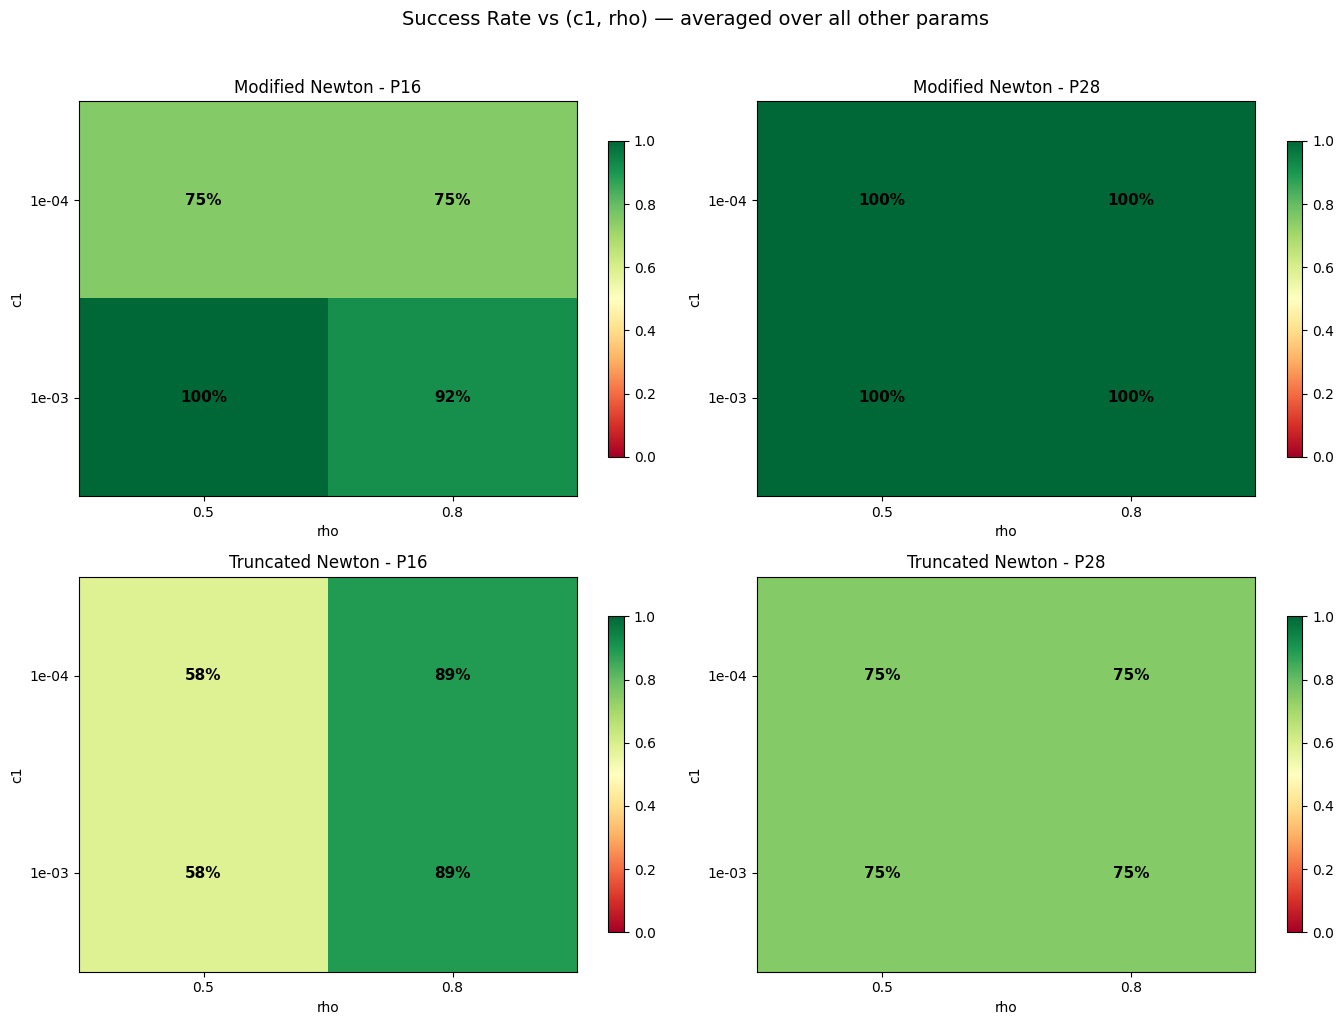

In [ ]:
# Heatmaps: success rate vs (c1, rho)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, (df, method_name) in enumerate(
        [(mn_df, 'Modified Newton'), (tn_df, 'Truncated Newton')]):
    for col_idx, prob_id in enumerate(('P16', 'P28')):
        ax = axes[row_idx, col_idx]
        sub = df[df['problem'] == prob_id]
        if sub.empty:
            ax.set_title(f'{method_name} - {prob_id} (no data)')
            continue
        pivot = sub.groupby(['c1', 'rho'])['success'].mean().unstack('rho')
        im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f'{v}' for v in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f'{v:.0e}' for v in pivot.index])
        ax.set_xlabel('rho')
        ax.set_ylabel('c1')
        ax.set_title(f'{method_name} - {prob_id}')
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                ax.text(j, i, f'{pivot.values[i, j]:.0%}',
                        ha='center', va='center', fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Success Rate vs (c1, rho) â€” averaged over all other params',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

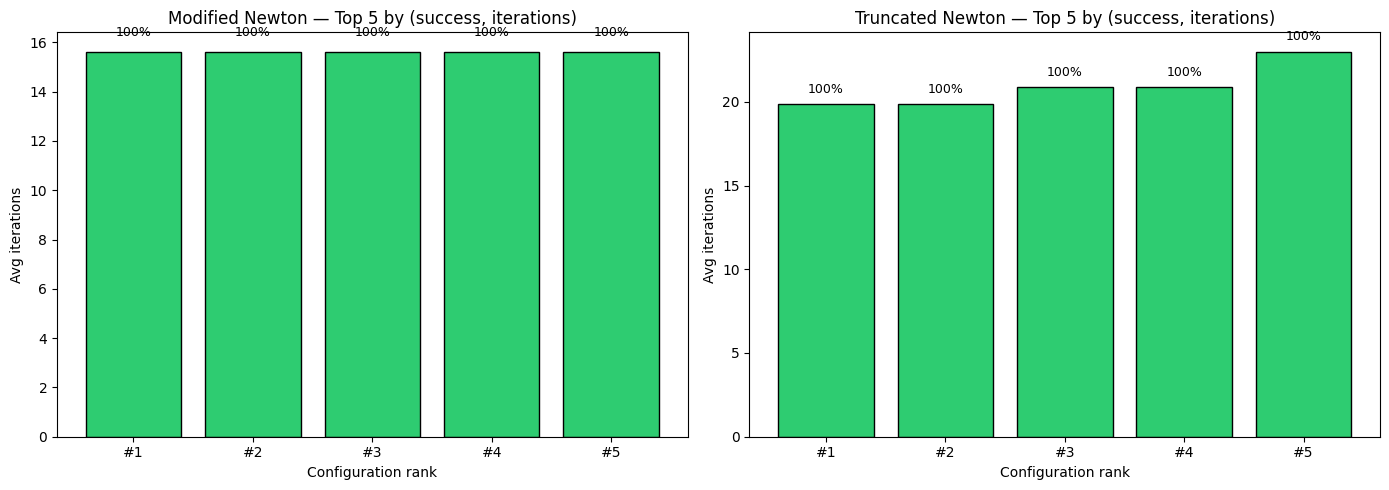

In [ ]:
# Top-5 configs bar chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (summary, name) in zip(axes,
        [(mn_summary, 'Modified Newton'), (tn_summary, 'Truncated Newton')]):
    top5 = summary.head(5)
    labels = [f"#{i+1}" for i in range(len(top5))]
    colors = ['#2ecc71' if s >= 0.99 else '#e74c3c' for s in top5['avg_success']]
    bars = ax.bar(labels, top5['avg_iter'], color=colors, edgecolor='black')
    ax.set_ylabel('Avg iterations')
    ax.set_xlabel('Configuration rank')
    ax.set_title(f'{name} â€” Top 5 by (success, iterations)')
    for bar, s in zip(bars, top5['avg_success']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{s:.0%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

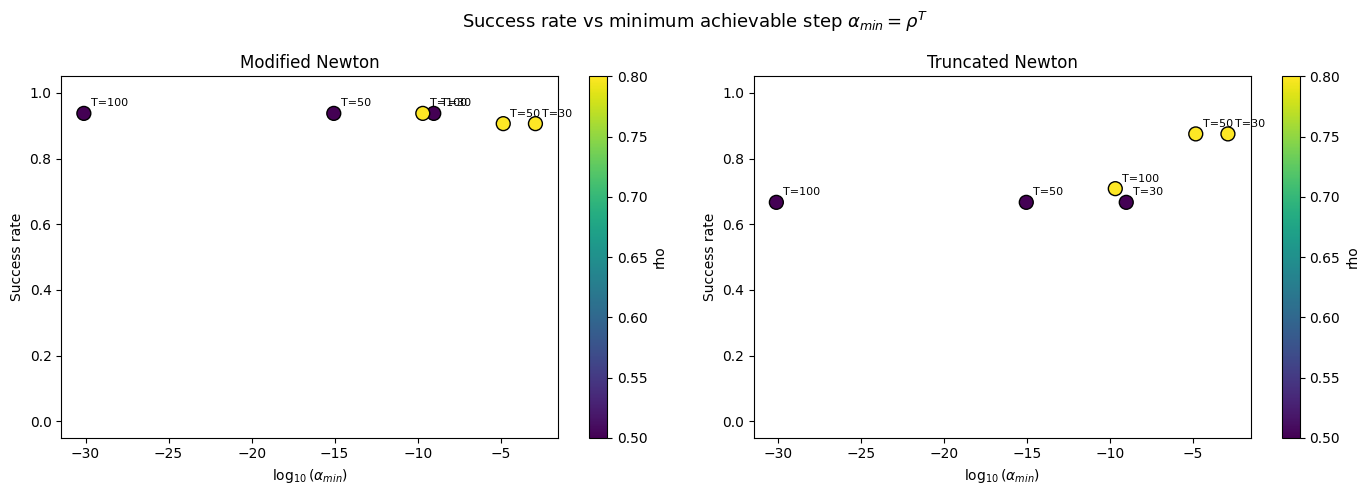

In [ ]:
# alpha_min vs success rate

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, name) in zip(axes,
        [(mn_df, 'Modified Newton'), (tn_df, 'Truncated Newton')]):
    sub = df.copy()
    sub['alpha_min'] = sub['rho'] ** sub['max_iter_bt']
    sub['log_alpha_min'] = np.log10(sub['alpha_min'])
    agg = sub.groupby(['rho', 'max_iter_bt']).agg(
        success_rate=('success', 'mean'),
        log_alpha_min=('log_alpha_min', 'first'),
    ).reset_index()
    scatter = ax.scatter(agg['log_alpha_min'], agg['success_rate'],
                         c=agg['rho'], cmap='viridis', s=100, edgecolor='black')
    for _, r in agg.iterrows():
        ax.annotate(f"T={int(r['max_iter_bt'])}",
                    (r['log_alpha_min'], r['success_rate']),
                    textcoords='offset points', xytext=(5, 5), fontsize=8)
    ax.set_xlabel(r'$\log_{10}(\alpha_{min})$')
    ax.set_ylabel('Success rate')
    ax.set_title(name)
    ax.set_ylim(-0.05, 1.05)
    plt.colorbar(scatter, ax=ax, label='rho')

plt.suptitle(r'Success rate vs minimum achievable step $\alpha_{min} = \rho^T$',
             fontsize=13)
plt.tight_layout()
plt.show()

<a id="phase2"></a>
## 6. Phase 2: Stopping Criteria Analysis

The stopping criterion does **not** affect the convergence trajectory â€” it only decides when to declare convergence. We fix the best method parameters from Phase 1 and analyze different stopping strategies post-hoc on the recorded trajectory.

### Tolerance Bands (from course slides)

The slides define 3 tolerance bands for relative x-change $\|x^{(k+1)} - x^{(k)}\| / \|x^{(k+1)}\| \leq \text{TOL}$:

| Band | TOL | Quality |
|------|-----|---------|
| **Rough** | $10^{-4}$ | Rough precision |
| **Good** | $10^{-8}$ | Good solution |
| **Very good** | $10^{-12}$ | Very demanding, often unnecessary |

**NOT acceptable** for relative criteria: TOL $= \varepsilon_m$ (machine precision $\approx 10^{-16}$).

### Adapted per criterion type

Using $|\Delta F| \approx \|\nabla f\| \cdot \|\Delta x\| \approx \|\nabla f\|^2$ near a minimum:

| Band | grad / x criteria | f-change criteria |
|------|-------------------|-------------------|
| Rough | $10^{-4}$ | $10^{-8}$ |
| Good | $10^{-8}$ | $10^{-16}$ (machine precision!) |
| Very good | $10^{-12}$ | $10^{-24}$ (impossible in float64) |

**Key insight**: f-change criteria are limited to the "rough" band. At "good" tolerance they hit machine precision.

In [ ]:
# Tolerance bands adapted per criterion type

TOLERANCE_BANDS = {
    #              (tol_grad,  tol_f,    tol_x)
    'rough':       (1e-4,      1e-8,     1e-4),
    'good':        (1e-8,      1e-16,    1e-8),
    'very_good':   (1e-12,     None,     1e-12),  # None = f-change not feasible
}

def make_stopping_config(crit_type, band):
    """Create (label, StoppingCriterion) for a given type and band.

    Returns None if the combination is not feasible (e.g., f-change at 'very_good').
    """
    tol_g, tol_f, tol_x = TOLERANCE_BANDS[band]
    factories = {
        'grad_abs':     (tol_g, lambda t: GradNormAbsolute(t)),
        'grad_rel':     (tol_g, lambda t: GradNormRelative(t)),
        'f_abs':        (tol_f, lambda t: FChangeAbsolute(t)),
        'f_rel':        (tol_f, lambda t: FChangeRelative(t)),
        'x_abs':        (tol_x, lambda t: XChangeAbsolute(t)),
        'x_rel':        (tol_x, lambda t: XChangeRelative(t)),
        'combined_abs': (None,  lambda _: CombinedStoppingCriterion([
                            GradNormAbsolute(tol_g),
                            *([FChangeAbsolute(tol_f)] if tol_f is not None else []),
                            XChangeAbsolute(tol_x)])),
        'combined_rel': (None,  lambda _: CombinedStoppingCriterion([
                            GradNormRelative(tol_g),
                            *([FChangeRelative(tol_f)] if tol_f is not None else []),
                            XChangeRelative(tol_x)])),
    }
    tol, factory = factories[crit_type]
    if tol is None and crit_type in ('f_abs', 'f_rel'):
        return None
    return factory(tol)

# Build all feasible (crit_type, band) pairs
CRIT_TYPES = ['grad_abs', 'grad_rel', 'f_abs', 'f_rel',
              'x_abs', 'x_rel', 'combined_abs', 'combined_rel']
BANDS = ['rough', 'good', 'very_good']

sc_configs = []
for crit_type in CRIT_TYPES:
    for band in BANDS:
        sc = make_stopping_config(crit_type, band)
        if sc is not None:
            sc_configs.append((crit_type, band, sc))

print(f"{len(sc_configs)} feasible (criterion, band) configurations:")
for ct, b, _ in sc_configs:
    tol_g, tol_f, tol_x = TOLERANCE_BANDS[b]
    print(f"  {ct:15s} @ {b:10s}  "
          f"(tol_g={tol_g:.0e}, tol_f={'N/A' if tol_f is None else f'{tol_f:.0e}'}, "
          f"tol_x={tol_x:.0e})")

22 feasible (criterion, band) configurations:
  grad_abs        @ rough       (tol_g=1e-04, tol_f=1e-08, tol_x=1e-04)
  grad_abs        @ good        (tol_g=1e-08, tol_f=1e-16, tol_x=1e-08)
  grad_abs        @ very_good   (tol_g=1e-12, tol_f=N/A, tol_x=1e-12)
  grad_rel        @ rough       (tol_g=1e-04, tol_f=1e-08, tol_x=1e-04)
  grad_rel        @ good        (tol_g=1e-08, tol_f=1e-16, tol_x=1e-08)
  grad_rel        @ very_good   (tol_g=1e-12, tol_f=N/A, tol_x=1e-12)
  f_abs           @ rough       (tol_g=1e-04, tol_f=1e-08, tol_x=1e-04)
  f_abs           @ good        (tol_g=1e-08, tol_f=1e-16, tol_x=1e-08)
  f_rel           @ rough       (tol_g=1e-04, tol_f=1e-08, tol_x=1e-04)
  f_rel           @ good        (tol_g=1e-08, tol_f=1e-16, tol_x=1e-08)
  x_abs           @ rough       (tol_g=1e-04, tol_f=1e-08, tol_x=1e-04)
  x_abs           @ good        (tol_g=1e-08, tol_f=1e-16, tol_x=1e-08)
  x_abs           @ very_good   (tol_g=1e-12, tol_f=N/A, tol_x=1e-12)
  x_rel           @ roug

In [ ]:
# Phase 2: run with each stopping criterion

best_mn_params = dict(
    c1=best_mn['c1'], rho=best_mn['rho'],
    beta=best_mn['beta'], max_tau_iter=int(best_mn['max_tau_iter']),
    max_iter_backtrack=int(best_mn['max_iter_bt']))

best_tn_params = dict(
    c1=best_tn['c1'], rho=best_tn['rho'],
    forcing=best_tn['forcing'],
    cg_max_iter=(None if best_tn['cg_max_iter'] == 'n'
                 else int(best_tn['cg_max_iter'])),
    max_iter_backtrack=int(best_tn['max_iter_bt']))

sc_rows = []
methods_config = [
    ('ModNewton',  modified_newton,  best_mn_params),
    ('TruncNewton', truncated_newton, best_tn_params),
]

total_sc = 0
for method_name, _, _ in methods_config:
    m_key = 'modified_newton' if 'Mod' in method_name else 'truncated_newton'
    for pid in ('P16', 'P28'):
        for n in DIMENSIONS:
            if not should_skip(pid, n, m_key):
                total_sc += len(sc_configs) * len(starts_cache[(pid, n)])

idx = 0
t0_total = time.perf_counter()
print(f"Stopping criteria sweep: {total_sc} experiments")
print("-" * 80)

for method_name, method_fn, params in methods_config:
    for prob_id in ('P16', 'P28'):
        pinfo = PROBLEMS[prob_id]
        for n in DIMENSIONS:
            if should_skip(prob_id, n, method_name.lower().replace("mod", "modified_").replace("trunc", "truncated_")):
                continue
            for crit_type, band, _ in sc_configs:
                for si, x0 in enumerate(starts_cache[(prob_id, n)]):
                    idx += 1
                    stop = make_stopping_config(crit_type, band)
                    t0 = time.perf_counter()
                    try:
                        res = method_fn(
                                pinfo['f'], x0, stop,
                                grad_f=pinfo['grad'],
                                hess_f=(pinfo['hess'] if method_name != 'TruncNewton' or expected_hessian_mb(n) <= OOM_THRESHOLD_MB else None),
                                alpha0=1.0, max_iter=MAX_ITER, **params, time_limit=TIME_LIMIT)
                        elapsed = time.perf_counter() - t0
                        tag = 'OK' if res['success'] else 'FAIL'
                        print(f"[{idx:>4d}/{total_sc}] {tag}  {method_name:11s} "
                              f"{prob_id} n={n:<6d} s={si} "
                              f"{crit_type:13s} {band:10s} | "
                              f"it={res['n_iter']:>3d} ||g||={res['grad_norm']:.2e} "
                              f"t={elapsed:.2f}s  [{res['stop_reason']}]")
                        row = dict(
                            method=method_name, problem=prob_id, n=n,
                            start_idx=si, crit_type=crit_type, band=band,
                            n_iter=res['n_iter'], success=res['success'],
                            grad_norm=res['grad_norm'], f_star=res['f_star'],
                            time_s=elapsed, stop_reason=res['stop_reason'])
                    except Exception as e:
                        print(f"[{idx:>4d}/{total_sc}] ERR  {method_name:11s} "
                              f"{prob_id} n={n:<6d} s={si} "
                              f"{crit_type:13s} {band:10s} | {e}")
                        row = dict(
                            method=method_name, problem=prob_id, n=n,
                            start_idx=si, crit_type=crit_type, band=band,
                            n_iter=0, success=False,
                            grad_norm=np.nan, f_star=np.nan,
                            time_s=time.perf_counter() - t0,
                            stop_reason=f'err:{type(e).__name__}')
                    sc_rows.append(row)

sc_df = pd.DataFrame(sc_rows)
elapsed_total = time.perf_counter() - t0_total
print("-" * 80)
print(f"Stopping criteria DONE: {len(sc_df)} runs in {elapsed_total:.1f}s")


In [ ]:
# Stopping criteria: aggregation and tables

sc_agg = sc_df.groupby(['method', 'crit_type', 'band']).agg(
    success_rate=('success', 'mean'),
    mean_iter=('n_iter', 'mean'),
    std_iter=('n_iter', 'std'),
    mean_grad=('grad_norm', lambda s: np.nanmean(s)),
    mean_fstar=('f_star', lambda s: np.nanmean(s)),
    mean_time=('time_s', 'mean'),
).reset_index()

for method in ('ModNewton', 'TruncNewton'):
    print(f"\n=== Stopping Criteria â€” {method} ===")
    sub = sc_agg[sc_agg['method'] == method].sort_values(['band', 'crit_type'])
    print(sub.to_string(index=False))


=== Stopping Criteria â€” ModNewton ===
   method    crit_type      band  success_rate  mean_iter  std_iter    mean_grad    mean_fstar  mean_time
ModNewton combined_abs      good         1.000     15.625 13.927747 6.783840e-10 -1.072192e+02   1.583480
ModNewton combined_rel      good         1.000     10.000  5.606119 1.137640e+12  7.778355e+09   1.363658
ModNewton        f_abs      good         1.000     16.250 13.456278 6.775294e-10 -1.072192e+02   1.511562
ModNewton        f_rel      good         1.000     16.250 13.456278 6.775294e-10 -1.072192e+02   1.874911
ModNewton     grad_abs      good         1.000     15.625 13.927747 6.783840e-10 -1.072192e+02   1.410892
ModNewton     grad_rel      good         1.000     10.000  5.606119 1.137640e+12  7.778355e+09   1.212941
ModNewton        x_abs      good         1.000     16.375 13.490076 6.775294e-10 -1.072192e+02   1.673545
ModNewton        x_rel      good         1.000     15.750 13.220655 5.061415e-06 -1.072192e+02   1.813328
ModNe

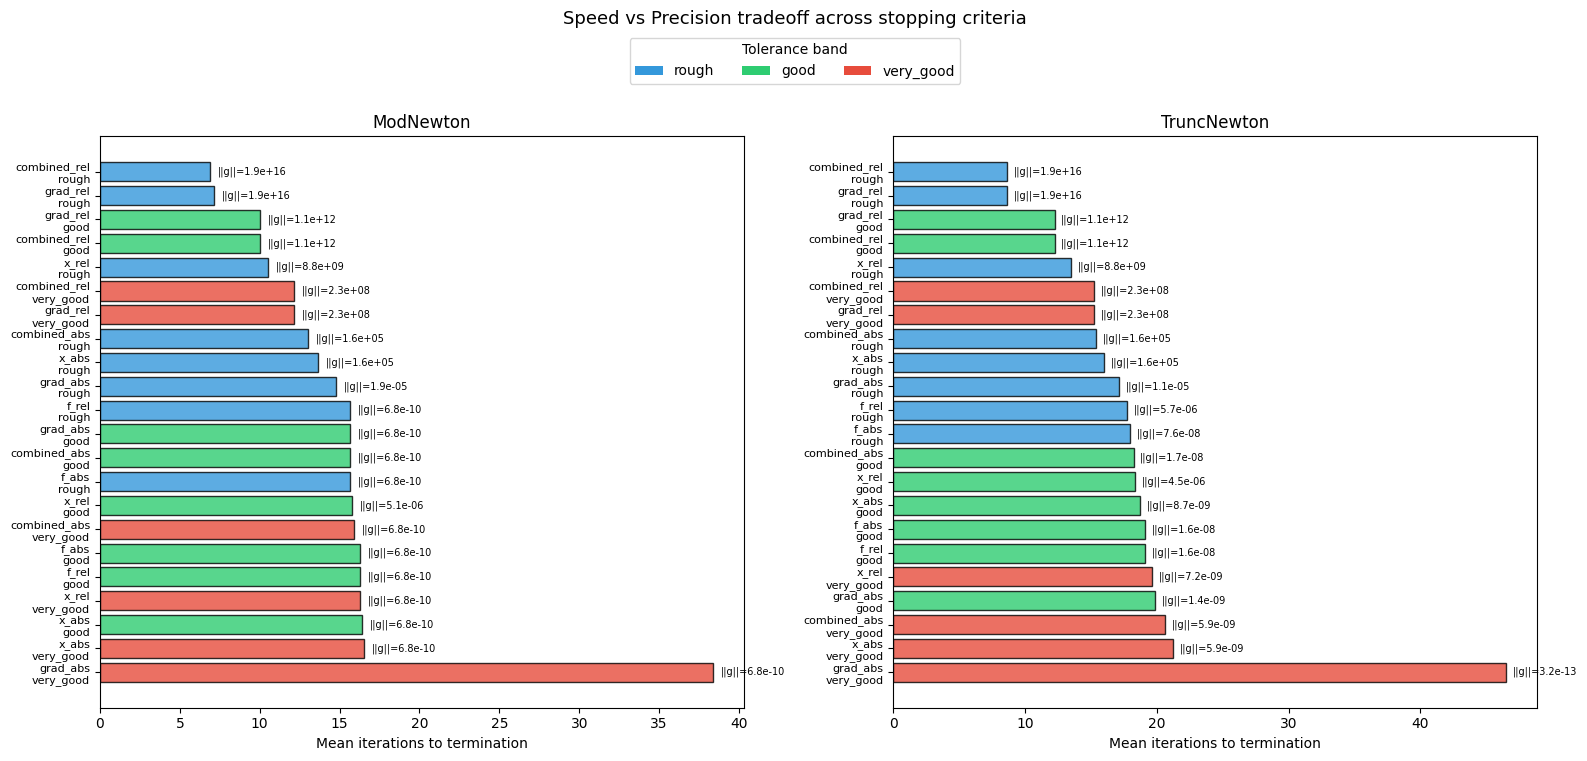

In [ ]:
# Stopping criteria: visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, method in zip(axes, ('ModNewton', 'TruncNewton')):
    sub = sc_agg[sc_agg['method'] == method].copy()
    sub['label'] = sub['crit_type'] + '\n' + sub['band']
    sub = sub.sort_values('mean_iter')

    colors = {'rough': '#3498db', 'good': '#2ecc71', 'very_good': '#e74c3c'}
    bar_colors = [colors[b] for b in sub['band']]

    bars = ax.barh(range(len(sub)), sub['mean_iter'],
                   color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['label'], fontsize=8)
    ax.set_xlabel('Mean iterations to termination')
    ax.set_title(method)
    ax.invert_yaxis()

    for i, (_, r) in enumerate(sub.iterrows()):
        ax.text(r['mean_iter'] + 0.5, i,
                f"||g||={r['mean_grad']:.1e}", va='center', fontsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=b) for b, c in colors.items()]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           title='Tolerance band', bbox_to_anchor=(0.5, 1.05))

plt.suptitle('Speed vs Precision tradeoff across stopping criteria',
             fontsize=13, y=1.08)
plt.tight_layout()
plt.show()

<a id="export"></a>
## 7. Export & Summary

In [ ]:
# Save results to CSV

results_dir = ROOT / 'results'
results_dir.mkdir(exist_ok=True)

mn_df.to_csv(results_dir / 'fine_tuning_modified_newton.csv', index=False)
tn_df.to_csv(results_dir / 'fine_tuning_truncated_newton.csv', index=False)
sc_df.to_csv(results_dir / 'fine_tuning_stopping_criteria.csv', index=False)

print(f"Saved to {results_dir}/:")
print(f"  fine_tuning_modified_newton.csv   ({len(mn_df)} rows)")
print(f"  fine_tuning_truncated_newton.csv  ({len(tn_df)} rows)")
print(f"  fine_tuning_stopping_criteria.csv ({len(sc_df)} rows)")

Saved to c:\Users\andre\Documents\University\2nd Year\NO4LSP\project\Unconstrained_Optimization_Project\results/:
  fine_tuning_modified_newton.csv   (384 rows)
  fine_tuning_truncated_newton.csv  (576 rows)
  fine_tuning_stopping_criteria.csv (352 rows)


In [ ]:
# Final summary

print("=" * 70)
print("FINE-TUNING SUMMARY")
print("=" * 70)
print(f"SEED: {SEED}")
print(f"QUICK_MODE: {QUICK_MODE}")
print(f"Dimensions: {DIMENSIONS}")
print(f"Starting points: {1 + NUM_RANDOM} per (problem, n)")
print(f"MAX_ITER: {MAX_ITER}")
print()
print("BEST MODIFIED NEWTON:")
print(f"  c1={best_mn['c1']:.0e}, rho={best_mn['rho']}, "
      f"beta={best_mn['beta']:.0e}")
print(f"  max_tau_iter={int(best_mn['max_tau_iter'])}, "
      f"max_iter_backtrack={int(best_mn['max_iter_bt'])}")
print(f"  success rate: {best_mn['avg_success']:.2%}")
print(f"  avg iterations: {best_mn['avg_iter']:.1f}")
print()
print("BEST TRUNCATED NEWTON:")
print(f"  c1={best_tn['c1']:.0e}, rho={best_tn['rho']}, "
      f"forcing={best_tn['forcing']}")
print(f"  cg_max_iter={best_tn['cg_max_iter']}, "
      f"max_iter_backtrack={int(best_tn['max_iter_bt'])}")
print(f"  success rate: {best_tn['avg_success']:.2%}")
print(f"  avg iterations: {best_tn['avg_iter']:.1f}")
print()
print("=" * 70)

FINE-TUNING SUMMARY
SEED: 323334
QUICK_MODE: True
Dimensions: [2, 1000]
Starting points: 2 per (problem, n)
MAX_ITER: 200

BEST MODIFIED NEWTON:
  c1=1e-03, rho=0.5, beta=1e-03
  max_tau_iter=50, max_iter_backtrack=30
  success rate: 100.00%
  avg iterations: 15.6

BEST TRUNCATED NEWTON:
  c1=1e-04, rho=0.8, forcing=quadratic
  cg_max_iter=50, max_iter_backtrack=30
  success rate: 100.00%
  avg iterations: 19.9

